Analysing data of Global tech talent and workforce survey gotten from kaggle.com

In [3]:
#first steps:
#importing libraries to work with the dataset

import pandas as pd
import numpy as np

df = pd.read_csv('saas-sample-500.csv')
#checking the dataset
df.head()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   productId          354 non-null    str  
 1   name               354 non-null    str  
 2   tagline            354 non-null    str  
 3   description        354 non-null    str  
 4   url                354 non-null    str  
 5   websiteUrl         354 non-null    str  
 6   avatarUrl          354 non-null    str  
 7   monthlyRevenueUSD  354 non-null    int64
 8   numFollowers       354 non-null    int64
 9   twitterHandle      124 non-null    str  
 10  startDate          354 non-null    str  
 11  createdAt          354 non-null    str  
 12  publishedAt        354 non-null    str  
 13  updatedAt          354 non-null    str  
 14  founderUserIds     354 non-null    str  
 15  verticals          354 non-null    str  
 16  revenueModels      354 non-null    str  
 17  funding            354 non-

In [11]:
#setting data types for the columns
datecols = ['startDate', 'createdAt', 'publishedAt', 'scrapedAt']
print(f"{datecols}\nthe date columns")
df[datecols] = df[datecols].apply(pd.to_datetime, errors='coerce', format='ISO8601')
category_columns = df.select_dtypes(include = 'str').columns.tolist()
numeric_columns = df.select_dtypes(include = 'int64').columns.tolist()
timeseries_columns = df.select_dtypes(exclude=['object', 'int64', 'float64']).columns.tolist()
print(f"Category columns: {category_columns}")
print(f"Numeric columns: {numeric_columns}")
print(f"Timeseries columns: {timeseries_columns}")
# df.info()
#checking for missing values
missing_values = (df.isnull().sum()/len(df)*100).sort_values(ascending=False)
print(f"Missing values (%): \n{missing_values}")
# fill missing values in the handle and platform columns with 'Unknown'
df.fillna({'twitterHandle': 'Unknown', 'platforms': 'Unknown'}, inplace=True)
print(df.columns)
keycolumns = ['productId', 'url', 'tagline', 'monthlyRevenueUSD', 'numFollowers', 'platforms', 'revenueModels', 'verticals', 'funding', 'startDate', 'createdAt', 'publishedAt', 'scrapedAt']
df[keycolumns].describe().transpose() #generating summary statistics for the key columns of the dataset
df[keycolumns].describe(include='object').transpose() #generating summary statistics for the categorical columns of the dataset


['startDate', 'createdAt', 'publishedAt', 'scrapedAt']
the date columns
Category columns: ['productId', 'name', 'tagline', 'description', 'url', 'websiteUrl', 'avatarUrl', 'twitterHandle', 'updatedAt', 'founderUserIds', 'verticals', 'revenueModels', 'funding', 'platforms', 'allTags']
Numeric columns: ['monthlyRevenueUSD', 'numFollowers']
Timeseries columns: ['startDate', 'createdAt', 'publishedAt', 'scrapedAt']
Missing values (%): 
productId            0.0
name                 0.0
tagline              0.0
description          0.0
url                  0.0
websiteUrl           0.0
avatarUrl            0.0
monthlyRevenueUSD    0.0
numFollowers         0.0
twitterHandle        0.0
startDate            0.0
createdAt            0.0
publishedAt          0.0
updatedAt            0.0
founderUserIds       0.0
verticals            0.0
revenueModels        0.0
funding              0.0
platforms            0.0
allTags              0.0
scrapedAt            0.0
dtype: float64
Index(['productId', 'nam

C:\Users\ibien\AppData\Local\Temp\ipykernel_2448\3803339636.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df[keycolumns].describe(include='object').transpose() #generating summary statistics for the categorical columns of the dataset


,count,unique,top,freq
productId,354,354,party-invitation-ai,1
url,354,354,https://www.indiehackers.com/product/party-inv...,1
tagline,354,353,14-Day System to Recover Lost Revenue & 2–5x Y...,2
platforms,354,55,web,156
revenueModels,354,41,subscription,154
verticals,354,327,ai,7
funding,354,12,self,209


In [29]:
total_observations = len(df)
print(f'Total observations: {total_observations}')

average_monthly_revenue = df['monthlyRevenueUSD'].mean()
median_monthly_revenue = df['monthlyRevenueUSD'].median()
max_monthly_revenue = df['monthlyRevenueUSD'].max()
total_monthly_revenue = df['monthlyRevenueUSD'].sum()
lowest_monthly_revenue = df['monthlyRevenueUSD'].min()
print(f'Total monthly revenue: ${total_monthly_revenue:,.2f} and the maximum monthly revenue is ${max_monthly_revenue:,.2f} and the lowest monthly revenue is ${lowest_monthly_revenue:,.2f}')
print(f'Average monthly revenue: ${average_monthly_revenue:,.2f} but the realistic rate a person is making is ${median_monthly_revenue:.2f} per month')
average_followers = df['numFollowers'].mean().round(0)
median_followers = df['numFollowers'].median().round(0)
total_followers = df['numFollowers'].sum()
print(f'The Average number of followers a person has is {average_followers}\n total followers across all repondendts is {total_followers}')
df['startDate'].dt.to_period('Y').value_counts()
low_earners =df[df['monthlyRevenueUSD'] == 0].count()
print(f'The number of low earners (earning $0 or less) is {low_earners["monthlyRevenueUSD"]}')

Total observations: 354
Total monthly revenue: $568,711,116.00 and the maximum monthly revenue is $567,890,678.00 and the lowest monthly revenue is $0.00
Average monthly revenue: $1,606,528.58 but the realistic rate a person is making is $0.00 per month
The Average number of followers a person has is 1.0
 total followers across all repondendts is 353
The number of low earners (earning $0 or less) is 247


The revenue earned across is the entire population is heavily skewed as a vast majority of persons not earning is 247, reprenting almost 70% of the observed group.

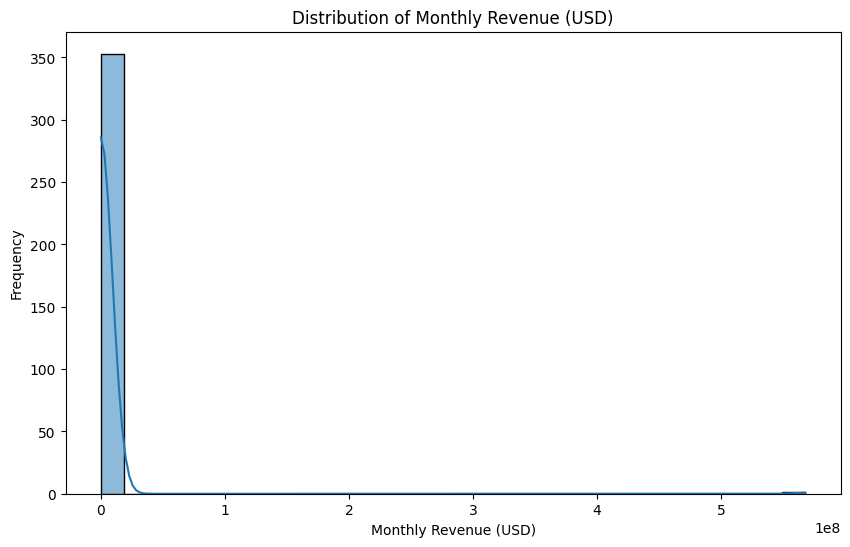

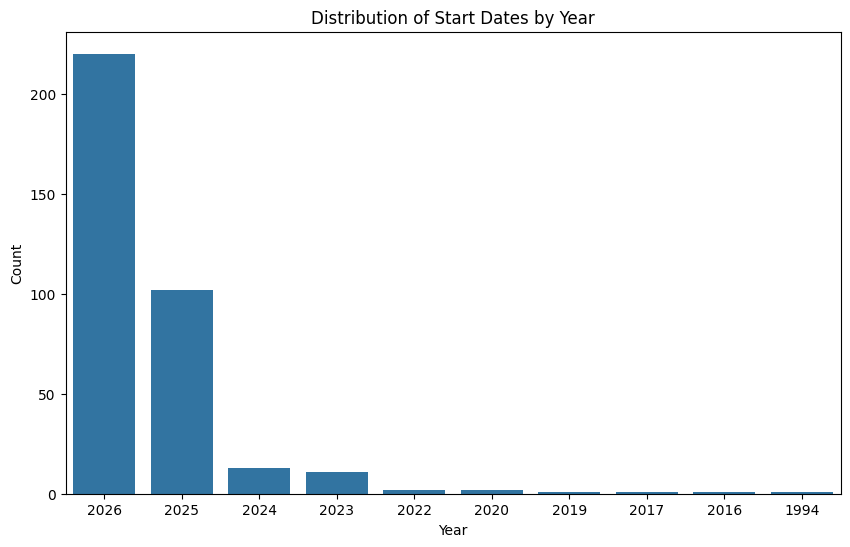

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(df['monthlyRevenueUSD'], bins=30, kde=True)
plt.title('Distribution of Monthly Revenue (USD)')
plt.xlabel('Monthly Revenue (USD)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=df['startDate'].dt.to_period('Y').value_counts().index.astype(str).sort_values(ascending=False), y=df['startDate'].dt.to_period('Y').value_counts().values)
plt.title('Distribution of Start Dates by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()